# Data Cleaning 

Here we will clean the data collected from the ESP32 serial monitor output.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('data/01-original-data.csv')
print(df.head(5))

   78.00   23.00
0   78.0    23.0
1   78.0    23.9
2   78.0    23.9
3   78.0    23.9
4   78.0    23.9


Up next we will add names to the columns and get to know more overall info about our dataset.

In [39]:
headers = ['humidity', 'temperature_celcius']
df.columns = headers

print("-----------------------------------------------")
print(df.head())
print("-----------------------------------------------")
print(df.describe())
print("-----------------------------------------------")
print(df.info)
print("-----------------------------------------------")

-----------------------------------------------
   humidity  temperature_celcius
0      78.0                 23.0
1      78.0                 23.9
2      78.0                 23.9
3      78.0                 23.9
4      78.0                 23.9
-----------------------------------------------
         humidity  temperature_celcius
count  855.000000           855.000000
mean    76.149708            25.938246
std      8.839635             2.020052
min     66.000000            23.000000
25%     68.000000            23.900000
50%     78.000000            25.900000
75%     78.000000            27.500000
max     93.000000            29.800000
-----------------------------------------------
<bound method DataFrame.info of      humidity  temperature_celcius
0        78.0                 23.0
1        78.0                 23.9
2        78.0                 23.9
3        78.0                 23.9
4        78.0                 23.9
..        ...                  ...
850      71.0                 

Now we will add another column to our dataset that is our target column. Which is either high / low depending on the temperature. and humidity.

In [40]:
df['status_temperature'] = np.where(df.temperature_celcius > 25, 'High', 'Low')
df['status_humidity'] = np.where(df.humidity > 70, 'High', 'Low')

In [41]:
df.head()

,humidity,temperature_celcius,status_temperature,status_humidity
0,78.0,23.0,Low,High
1,78.0,23.9,Low,High
2,78.0,23.9,Low,High
3,78.0,23.9,Low,High
4,78.0,23.9,Low,High


<Axes: xlabel='temperature_celcius', ylabel='humidity'>

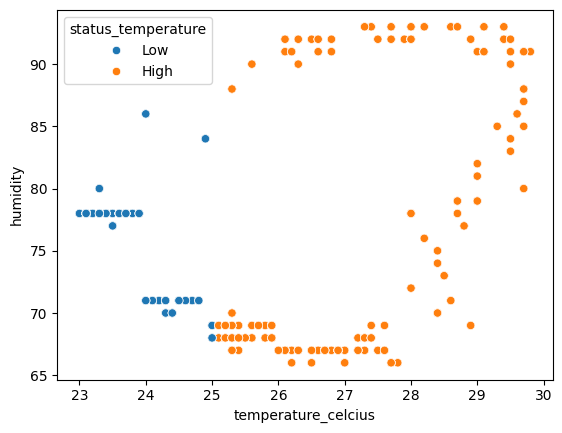

In [42]:
sns.scatterplot(x='temperature_celcius', y='humidity', hue='status_temperature', data=df)

<Axes: xlabel='temperature_celcius', ylabel='humidity'>

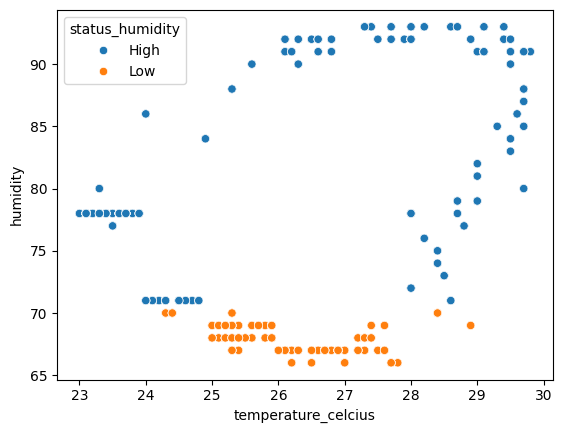

In [45]:
sns.scatterplot(x='temperature_celcius', y='humidity', hue='status_humidity', data=df)

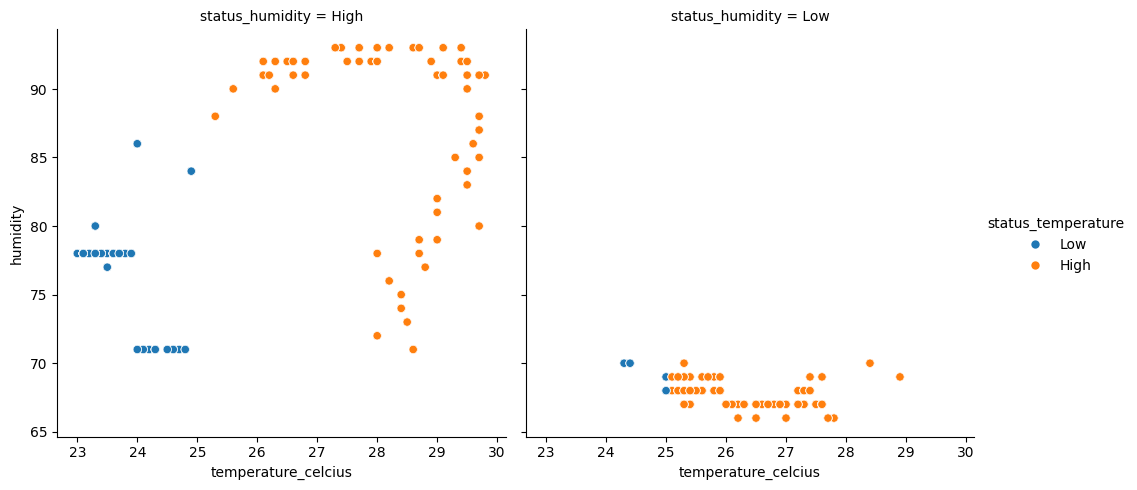

In [48]:
sns.relplot(
    data=df,
    x="temperature_celcius",
    y="humidity",
    hue="status_temperature",
    col="status_humidity",
    kind="scatter",
)

In [51]:
df.to_csv("data/02-cleaned_data.csv")